# MATH 210 Introduction to Mathematical Computing

**March 30, 2026**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

## Interpolation

Write a function called `interpolate` which takes sequences `x` and `y` (of the same length), and returns a NumPy array consisting of the coefficients of the unique polynomial of degree (at most) $d$ which interpolates the data (where `d = len(x) - 1`).

In [2]:
def interpolate(x,y):
    A = np.vander(x,increasing=True)
    c = la.solve(A,y)
    return c

In [3]:
x = [0.,1.,2.,3.]
y = [0.,0.,0.,1.]
c = interpolate(x,y)
print(c,[0.,1/3,-1/2,1/6])

[ 0.          0.33333333 -0.5         0.16666667] [0.0, 0.3333333333333333, -0.5, 0.16666666666666666]


In [4]:
x = [-2,-1,0.,1.,2.]
y = [31.,5.,1.,1.,11.]
c = interpolate(x,y)
print(c,[1,-1,1,-1,1])

[ 1. -1.  1. -1.  1.] [1, -1, 1, -1, 1]


In [5]:
np.vander(x,increasing=True)

array([[ 1., -2.,  4., -8., 16.],
       [ 1., -1.,  1., -1.,  1.],
       [ 1.,  0.,  0.,  0.,  0.],
       [ 1.,  1.,  1.,  1.,  1.],
       [ 1.,  2.,  4.,  8., 16.]])

## Example

Write a function called `cpinterpolate` which takes sequences `x` and `y` (of the same length), and returns a NumPy array consisting of the coefficients of the unique polynomial $p(x)$ of degree (at most) $2n - 1$ which interpolates the data (where `n = len(x)`) and $p'(x_i) = 0$ for $i=0,\dots,n-1$.

In [6]:
x = np.array([1.,2.])
n = len(x)
A1 = np.column_stack([x**k for k in range(2*n)])
A2 = np.column_stack([np.zeros(n)] + [k*x**(k-1) for k in range(1,2*n)])
A = np.vstack([A1,A2])
A

array([[ 1.,  1.,  1.,  1.],
       [ 1.,  2.,  4.,  8.],
       [ 0.,  1.,  2.,  3.],
       [ 0.,  1.,  4., 12.]])

In [13]:
def cpinterpolate(x,y):
    n = len(x)
    x = np.array(x)
    A1 = np.column_stack([x**k for k in range(2*n)])
    A2 = np.column_stack([np.zeros(n)] + [k*x**(k-1) for k in range(1,2*n)])
    A = np.vstack([A1,A2])
    b = np.hstack([y,np.zeros(n)])
    c = la.solve(A,b)
    return c

In [14]:
x = [0.,1.]
y = [1.,-1.]
c = cpinterpolate(x,y)
c

array([ 1.,  0., -6.,  4.])

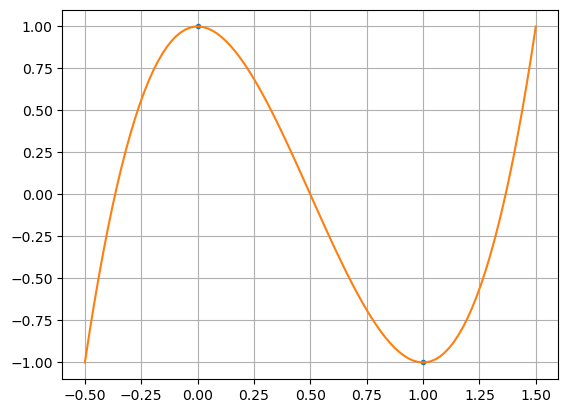

In [18]:
xs = np.linspace(-0.5,1.5,100)
ys = sum([c[k]*xs**k for k in range(len(c))])
plt.plot(x,y,'.',xs,ys)
plt.grid(True)
plt.show()

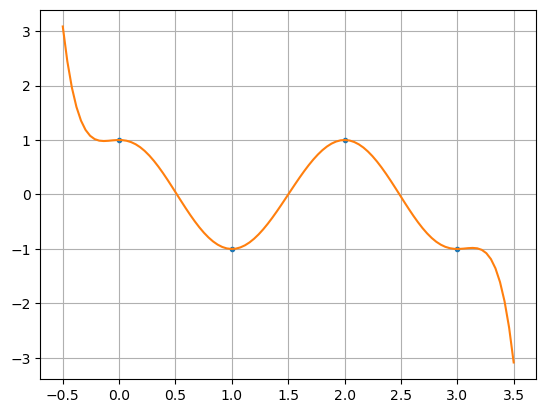

In [23]:
x = [0.,1.,2.,3.]
y = [1.,-1.,1.,-1.]
c = cpinterpolate(x,y)
xs = np.linspace(-0.5,3.5,100)
ys = sum([c[k]*xs**k for k in range(len(c))])
plt.plot(x,y,'.',xs,ys)
plt.grid(True)
plt.show()

In [24]:
c

array([ 1.00000000e+00, -3.78956126e-14, -2.66666667e+00, -9.18518519e+00,
        1.88888889e+01, -1.18518519e+01,  3.11111111e+00, -2.96296296e-01])